# Bayesian IRT Model — Results Analysis

**Dataset**: N_target = 10,000 responses | N_students = 500 | min_answers = 30 per student  
**Model**: Multidimensional 3PL IRT with 69 skill dimensions, response-time mixture, age/gender covariates  
**Estimation**: NUTS/HMC (2 chains × 300 warmup + 300 sampling) and Variational Inference (meanfield)  

Sections:
1. Setup & Load Outputs
2. MCMC Convergence Diagnostics
3. Global Parameter Posteriors (HMC vs VI)
4. Skill Structure (mu_skill, sigma_skill)
5. Question Difficulty Distribution
6. Posterior Predictive Check (y_rep)
7. Student Skill Profiles
8. LOO-CV / Model Fit
9. Report Conclusions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────────
OUTPUT_DIR = "."  # run from output/ directory; change if needed

# Load all outputs
summary    = pd.read_csv(f"{OUTPUT_DIR}/nuts_mcmc_summary.csv", index_col=0)
vi_summary = pd.read_csv(f"{OUTPUT_DIR}/vi_summary_comparison.csv", index_col=0)
vi_draws   = pd.read_csv(f"{OUTPUT_DIR}/vi_draws_full.csv")
y_rep      = pd.read_csv(f"{OUTPUT_DIR}/y_rep_draws.csv")
log_lik    = pd.read_csv(f"{OUTPUT_DIR}/log_lik_draws.csv")
student_df = pd.read_csv(f"{OUTPUT_DIR}/target_student_profiles.csv")

print("Loaded outputs:")
print(f"  MCMC summary rows : {len(summary):,}")
print(f"  y_rep shape       : {y_rep.shape}")
print(f"  log_lik shape     : {log_lik.shape}")
print(f"  VI draws shape    : {vi_draws.shape}")
print(f"  Student profiles  : {student_df.shape}")

Loaded outputs:
  MCMC summary rows : 94,641
  y_rep shape       : (600, 10000)
  log_lik shape     : (600, 10000)
  VI draws shape    : (2000, 5)
  Student profiles  : (600, 207)


## 1. MCMC Convergence Diagnostics

Key criteria:
- **R-hat < 1.01**: chains have mixed (strict); < 1.05 is acceptable  
- **N_Eff > 100**: effective sample size large enough for inference  
- **MCSE/StdDev < 0.1**: Monte Carlo error is small relative to posterior SD

In [2]:
# ── R-hat summary ─────────────────────────────────────────────────────────────
rhat = summary['R_hat'].dropna()
neff = summary['N_Eff'].dropna()

print("=" * 50)
print("R-hat summary (all parameters)")
print("=" * 50)
print(rhat.describe().round(4))
print(f"\nParameters with R-hat > 1.05 (concerning): {(rhat > 1.05).sum()}")
print(f"Parameters with R-hat > 1.01 (watch):      {(rhat > 1.01).sum()}")
print(f"Parameters with R-hat <= 1.01 (converged): {(rhat <= 1.01).sum()}")

print("\n" + "=" * 50)
print("N_Eff summary")
print("=" * 50)
print(neff.describe().round(1))
print(f"\nParameters with N_Eff < 100 (low): {(neff < 100).sum()}")

R-hat summary (all parameters)
count    94641.0000
mean         0.9990
std          0.0022
min          0.9967
25%          0.9975
50%          0.9983
75%          0.9998
max          1.0582
Name: R_hat, dtype: float64

Parameters with R-hat > 1.05 (concerning): 1
Parameters with R-hat > 1.01 (watch):      243
Parameters with R-hat <= 1.01 (converged): 94398

N_Eff summary
count    94641.0
mean       995.3
std        370.6
min         33.7
25%        683.8
50%        912.3
75%       1272.7
max       1666.9
Name: N_Eff, dtype: float64

Parameters with N_Eff < 100 (low): 7


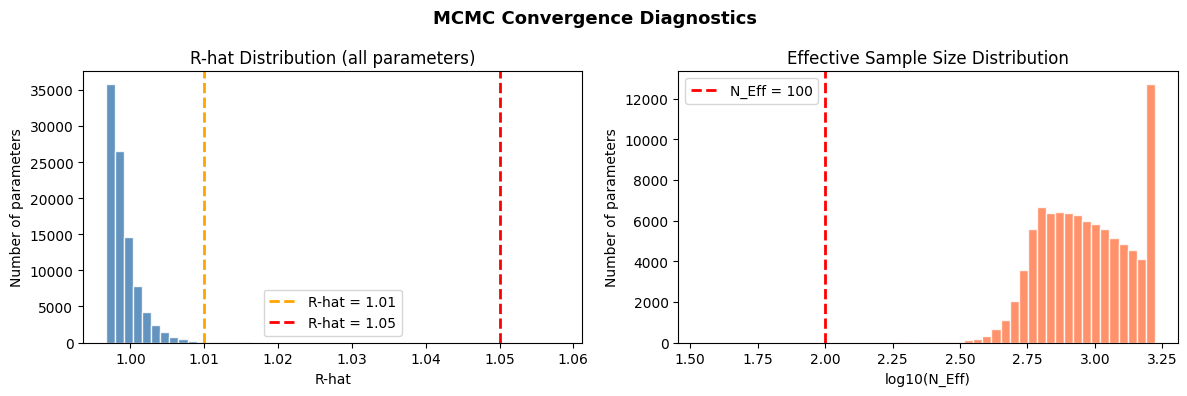

Saved convergence_diagnostics.png


In [3]:
# ── R-hat histogram ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(rhat, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(1.01, color='orange', lw=2, linestyle='--', label='R-hat = 1.01')
axes[0].axvline(1.05, color='red',    lw=2, linestyle='--', label='R-hat = 1.05')
axes[0].set_xlabel('R-hat')
axes[0].set_ylabel('Number of parameters')
axes[0].set_title('R-hat Distribution (all parameters)')
axes[0].legend()

axes[1].hist(np.log10(neff + 1), bins=50, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(np.log10(100), color='red', lw=2, linestyle='--', label='N_Eff = 100')
axes[1].set_xlabel('log10(N_Eff)')
axes[1].set_ylabel('Number of parameters')
axes[1].set_title('Effective Sample Size Distribution')
axes[1].legend()

plt.suptitle('MCMC Convergence Diagnostics', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/convergence_diagnostics.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved convergence_diagnostics.png")

In [5]:
# ── Key global parameters from MCMC summary ──────────────────────────────────
key_params = ['gamma_base', 'gamma_fast_delta', 'alpha', 'beta_time',
              'mu_log_time', 'sigma_log_time']
key_rows = summary.loc[summary.index.isin(key_params), 
                       ['Mean', 'StdDev', '5%', '50%', '95%', 'R_hat', 'N_Eff']]
print("Global parameters (HMC posterior):")
print(key_rows.round(4).to_string())

Global parameters (HMC posterior):
                    Mean  StdDev      5%     50%     95%   R_hat     N_Eff
gamma_base        0.1701  0.0202  0.1376  0.1705  0.2046  0.9993  195.9518
gamma_fast_delta  0.0619  0.0353  0.0075  0.0594  0.1276  0.9995  879.9839
alpha             0.8091  0.0317  0.7551  0.8102  0.8614  1.0192  191.1860
mu_log_time       5.8870  0.0108  5.8695  5.8872  5.9046  1.0016  525.4491
sigma_log_time    0.9889  0.0077  0.9764  0.9892  1.0015  0.9976  717.5732
beta_time         0.9250  0.0670  0.8286  0.9156  1.0499  0.9991  717.7400


## 2. Global Parameter Posteriors: HMC vs VI Comparison

In [6]:
# ── Build comparison table ───────────────────────────────────────────────────
hmc_global = summary.loc[summary.index.isin(key_params),
                          ['Mean', 'StdDev', '5%', '95%']].copy()
hmc_global.columns = ['HMC Mean', 'HMC SD', 'HMC 5%', 'HMC 95%']

vi_comp = vi_summary.T[['mean', 'std']].copy()
vi_comp.columns = ['VI Mean', 'VI SD']

comparison = hmc_global.join(vi_comp, how='left')
print("HMC vs VI Global Parameters:")
print(comparison.round(4).to_string())
comparison.round(4).to_csv(f"{OUTPUT_DIR}/hmc_vi_comparison_table.csv")
print("\nSaved hmc_vi_comparison_table.csv")

HMC vs VI Global Parameters:
                  HMC Mean  HMC SD  HMC 5%  HMC 95%  VI Mean   VI SD
gamma_base          0.1701  0.0202  0.1376   0.2046   0.2550  0.0072
gamma_fast_delta    0.0619  0.0353  0.0075   0.1276      NaN     NaN
alpha               0.8091  0.0317  0.7551   0.8614   0.6715  0.0097
mu_log_time         5.8870  0.0108  5.8695   5.9046   5.9283  0.0109
sigma_log_time      0.9889  0.0077  0.9764   1.0015   1.0056  0.0079
beta_time           0.9250  0.0670  0.8286   1.0499   0.9341  0.0503

Saved hmc_vi_comparison_table.csv


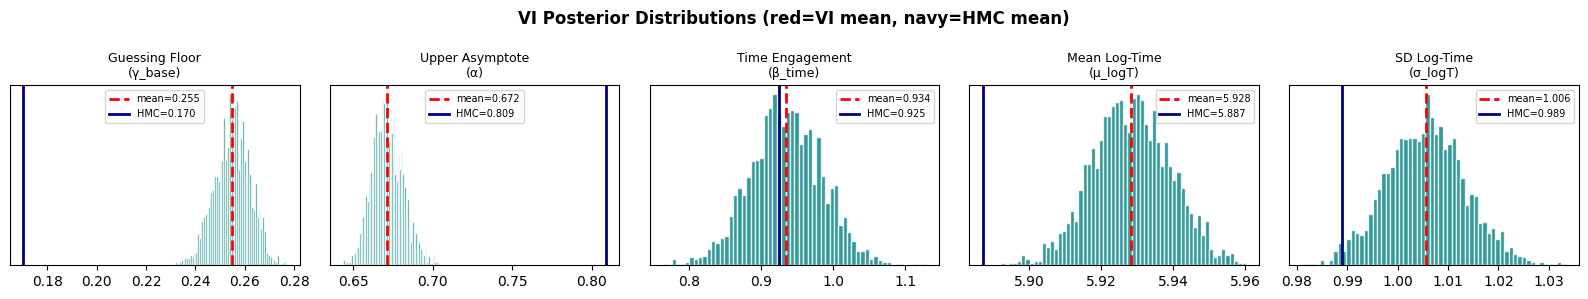

Saved vi_global_posteriors.png


In [7]:
# ── VI posterior density plots for global scalars ───────────────────────────
fig, axes = plt.subplots(1, len(vi_draws.columns), figsize=(16, 3))

nice_names = {
    'gamma_base':    'Guessing Floor\n(γ_base)',
    'alpha':         'Upper Asymptote\n(α)',
    'beta_time':     'Time Engagement\n(β_time)',
    'mu_log_time':   'Mean Log-Time\n(μ_logT)',
    'sigma_log_time':'SD Log-Time\n(σ_logT)'
}

for ax, col in zip(axes, vi_draws.columns):
    ax.hist(vi_draws[col], bins=60, color='teal', edgecolor='white', alpha=0.8)
    ax.axvline(vi_draws[col].mean(), color='red', lw=2, linestyle='--', label=f'mean={vi_draws[col].mean():.3f}')
    # HMC mean overlay if available
    if col in summary.index:
        ax.axvline(summary.loc[col, 'Mean'], color='navy', lw=2, linestyle='-', label=f'HMC={summary.loc[col,"Mean"]:.3f}')
    ax.set_title(nice_names.get(col, col), fontsize=9)
    ax.legend(fontsize=7)
    ax.set_yticks([])

plt.suptitle('VI Posterior Distributions (red=VI mean, navy=HMC mean)', fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/vi_global_posteriors.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved vi_global_posteriors.png")

## 3. Skill Structure: Population Mean and Variability

In [14]:
# ── Extract mu_skill and sigma_skill rows ────────────────────────────────────
mu_rows    = summary[summary.index.str.match(r'^mu_skill\[\d+\]$')].copy()
sigma_rows = summary[summary.index.str.match(r'^sigma_skill\[\d+\]$')].copy()

# Parse skill index — extract BEFORE reset so alignment is preserved
mu_skill_idx    = mu_rows.index.str.extract(r'\[(\d+)\]')[0].astype(int).values
sigma_skill_idx = sigma_rows.index.str.extract(r'\[(\d+)\]')[0].astype(int).values

mu_rows    = mu_rows.reset_index(drop=True)
sigma_rows = sigma_rows.reset_index(drop=True)

mu_rows['skill']    = mu_skill_idx
sigma_rows['skill'] = sigma_skill_idx

mu_rows    = mu_rows.sort_values('skill').reset_index(drop=True)
sigma_rows = sigma_rows.sort_values('skill').reset_index(drop=True)

print(f"Skills recovered: {len(mu_rows)} (expected 69)")
print(f"Skill range: {mu_rows['skill'].min()} – {mu_rows['skill'].max()}")
print("mu_skill summary (population average ability per skill):")
print(mu_rows['Mean'].describe().round(3))

Skills recovered: 69 (expected 69)
Skill range: 1 – 69
mu_skill summary (population average ability per skill):
count    69.000
mean     -0.300
std       0.411
min      -1.830
25%      -0.527
50%      -0.209
75%      -0.011
max       0.484
Name: Mean, dtype: float64


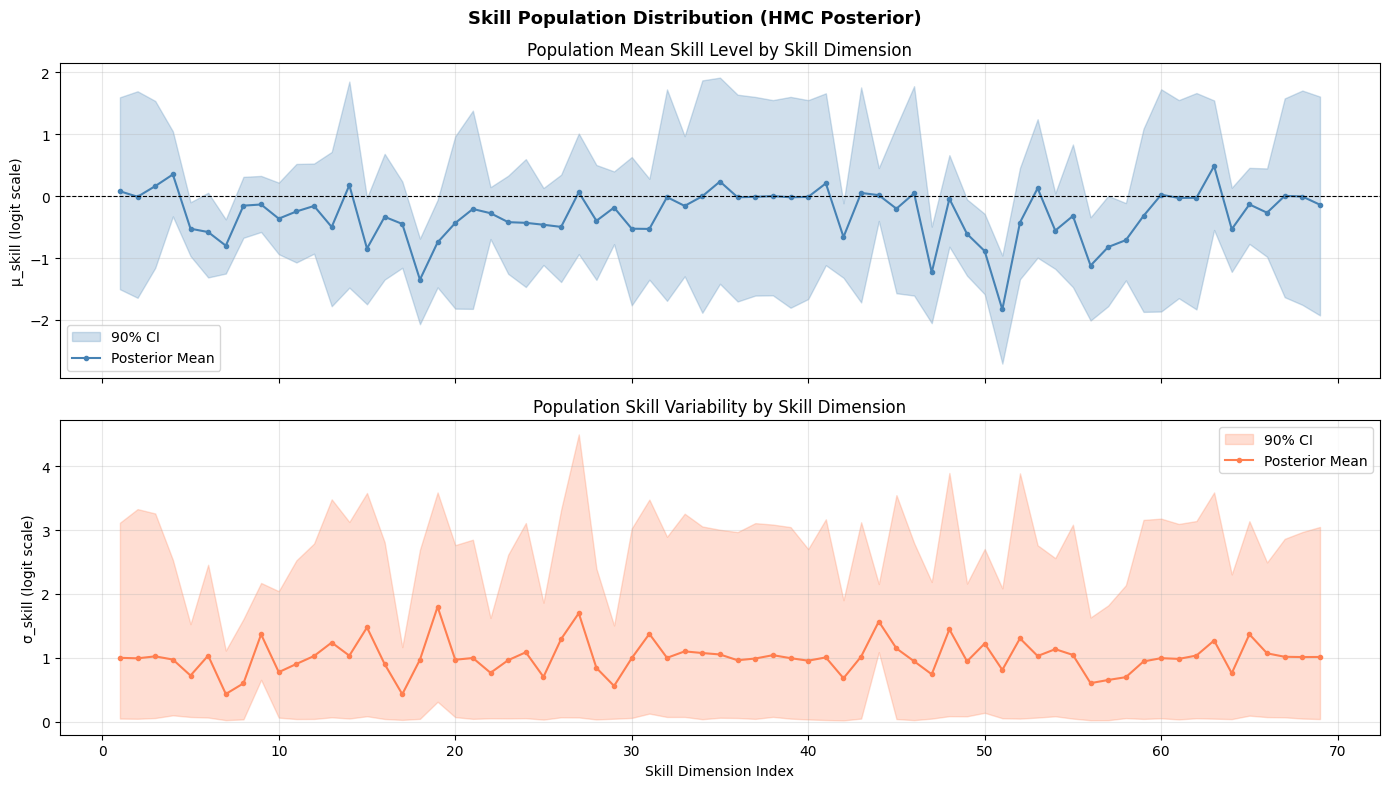

Saved skill_population.png


In [15]:
# ── Plot mu_skill and sigma_skill across all 69 skills ───────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

skills = mu_rows['skill'].values

# mu_skill with 90% CI
ax1.fill_between(skills, mu_rows['5%'].values, mu_rows['95%'].values, alpha=0.25, color='steelblue', label='90% CI')
ax1.plot(skills, mu_rows['Mean'].values, 'o-', color='steelblue', markersize=3, lw=1.5, label='Posterior Mean')
ax1.axhline(0, color='black', lw=0.8, linestyle='--')
ax1.set_ylabel('μ_skill (logit scale)')
ax1.set_title('Population Mean Skill Level by Skill Dimension')
ax1.legend()
ax1.grid(True, alpha=0.3)

# sigma_skill
ax2.fill_between(skills, sigma_rows['5%'].values, sigma_rows['95%'].values, alpha=0.25, color='coral', label='90% CI')
ax2.plot(skills, sigma_rows['Mean'].values, 'o-', color='coral', markersize=3, lw=1.5, label='Posterior Mean')
ax2.set_ylabel('σ_skill (logit scale)')
ax2.set_xlabel('Skill Dimension Index')
ax2.set_title('Population Skill Variability by Skill Dimension')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Skill Population Distribution (HMC Posterior)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/skill_population.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved skill_population.png")

## 4. Question Difficulty Distribution

Questions recovered: 5358

Question difficulty summary (logit scale):
count    5358.000
mean        0.004
std         0.290
min        -1.467
25%        -0.243
50%         0.097
75%         0.208
max         1.731
Name: Mean, dtype: float64


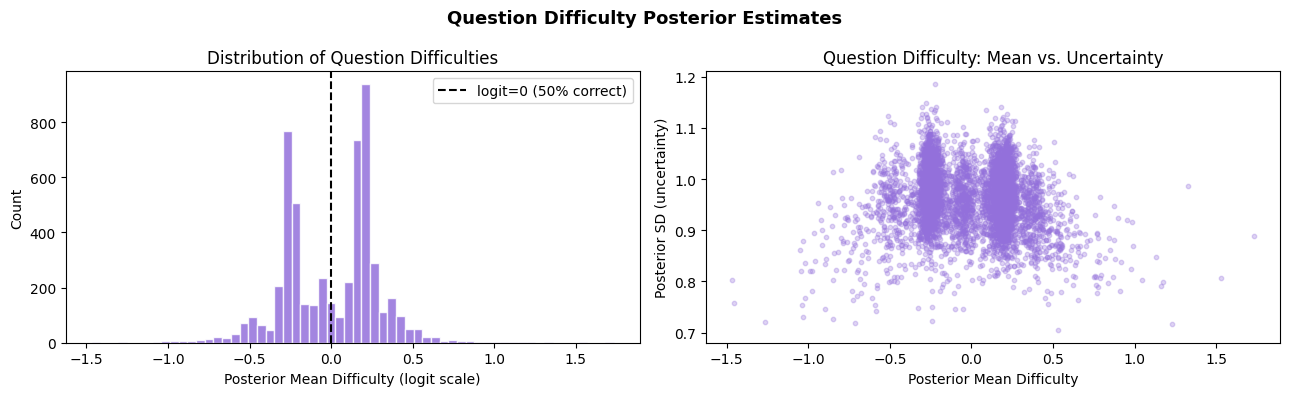

Saved question_difficulty.png


In [16]:
# ── Extract question difficulty ───────────────────────────────────────────────
diff_rows = summary[summary.index.str.match(r'^question_difficulty\[\d+\]$')].copy()
diff_rows['q_idx'] = diff_rows.index.str.extract(r'\[(\d+)\]').astype(int)

print(f"Questions recovered: {len(diff_rows)}")
print("\nQuestion difficulty summary (logit scale):")
print(diff_rows['Mean'].describe().round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram of difficulty
axes[0].hist(diff_rows['Mean'], bins=60, color='mediumpurple', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='black', lw=1.5, linestyle='--', label='logit=0 (50% correct)')
axes[0].set_xlabel('Posterior Mean Difficulty (logit scale)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Question Difficulties')
axes[0].legend()

# Difficulty vs posterior SD (uncertainty)
axes[1].scatter(diff_rows['Mean'], diff_rows['StdDev'], alpha=0.3, s=10, color='mediumpurple')
axes[1].set_xlabel('Posterior Mean Difficulty')
axes[1].set_ylabel('Posterior SD (uncertainty)')
axes[1].set_title('Question Difficulty: Mean vs. Uncertainty')

plt.suptitle('Question Difficulty Posterior Estimates', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/question_difficulty.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved question_difficulty.png")

## 5. Posterior Predictive Check (y_rep)

Observed mean accuracy:            0.4379
Posterior predictive mean:         0.4393
Difference (calibration error):    0.0014
90% interval of posterior draws: [0.4299, 0.4501]


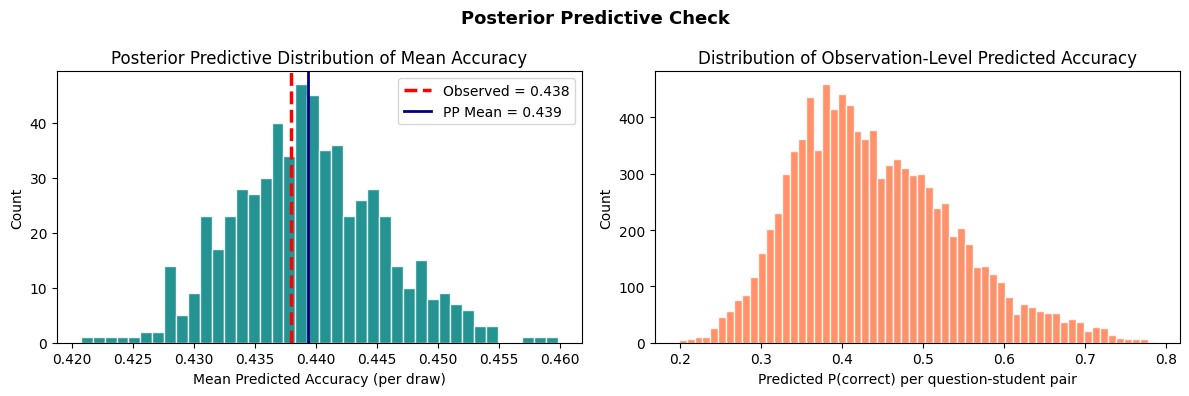

Saved posterior_predictive_check.png


In [17]:
# ── Compute per-draw accuracy ─────────────────────────────────────────────────
# Drop non-y_rep columns if present
yrep_cols = [c for c in y_rep.columns if c.startswith('y_rep')]
if not yrep_cols:
    yrep_cols = y_rep.columns.tolist()  # assume all columns are y_rep

yrep_matrix = y_rep[yrep_cols].values  # shape: (n_draws, n_obs)

# Per-draw mean accuracy
draw_means = yrep_matrix.mean(axis=1)

# Observed accuracy (mean over columns for the first draw as proxy)
# The actual observed mean was computed in bayesian.ipynb:
obs_mean = 0.4379  # from your bayesian.ipynb output — update if different
pp_mean  = draw_means.mean()

print(f"Observed mean accuracy:            {obs_mean:.4f}")
print(f"Posterior predictive mean:         {pp_mean:.4f}")
print(f"Difference (calibration error):    {abs(obs_mean - pp_mean):.4f}")
print(f"90% interval of posterior draws: [{np.percentile(draw_means,5):.4f}, {np.percentile(draw_means,95):.4f}]")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Per-draw accuracy histogram
axes[0].hist(draw_means, bins=40, color='teal', edgecolor='white', alpha=0.85)
axes[0].axvline(obs_mean, color='red', lw=2.5, linestyle='--', label=f'Observed = {obs_mean:.3f}')
axes[0].axvline(pp_mean,  color='navy', lw=2, linestyle='-',  label=f'PP Mean = {pp_mean:.3f}')
axes[0].set_xlabel('Mean Predicted Accuracy (per draw)')
axes[0].set_ylabel('Count')
axes[0].set_title('Posterior Predictive Distribution of Mean Accuracy')
axes[0].legend()

# Per-observation predicted accuracy across all draws
obs_pp_mean = yrep_matrix.mean(axis=0)  # mean across draws, per observation
axes[1].hist(obs_pp_mean, bins=60, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Predicted P(correct) per question-student pair')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Observation-Level Predicted Accuracy')

plt.suptitle('Posterior Predictive Check', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/posterior_predictive_check.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved posterior_predictive_check.png")

## 6. Student Skill Profiles

In [18]:
# ── Parse student profiles from draws ────────────────────────────────────────
# Columns are named like: user_skill[1,1], user_skill[1,2], ...
# Extract student index and skill index from column names

import re

student_profiles = {}
for col in student_df.columns:
    m = re.match(r'user_skill\[(\d+),(\d+)\]', col)
    if m:
        s_idx = int(m.group(1))
        k_idx = int(m.group(2))
        if s_idx not in student_profiles:
            student_profiles[s_idx] = {}
        student_profiles[s_idx][k_idx] = student_df[col].values  # draw array

students_found = sorted(student_profiles.keys())
print(f"Students found in profiles: {students_found}")
print(f"Skills per student: {len(student_profiles[students_found[0]])}")

Students found in profiles: [1, 2, 3]
Skills per student: 69


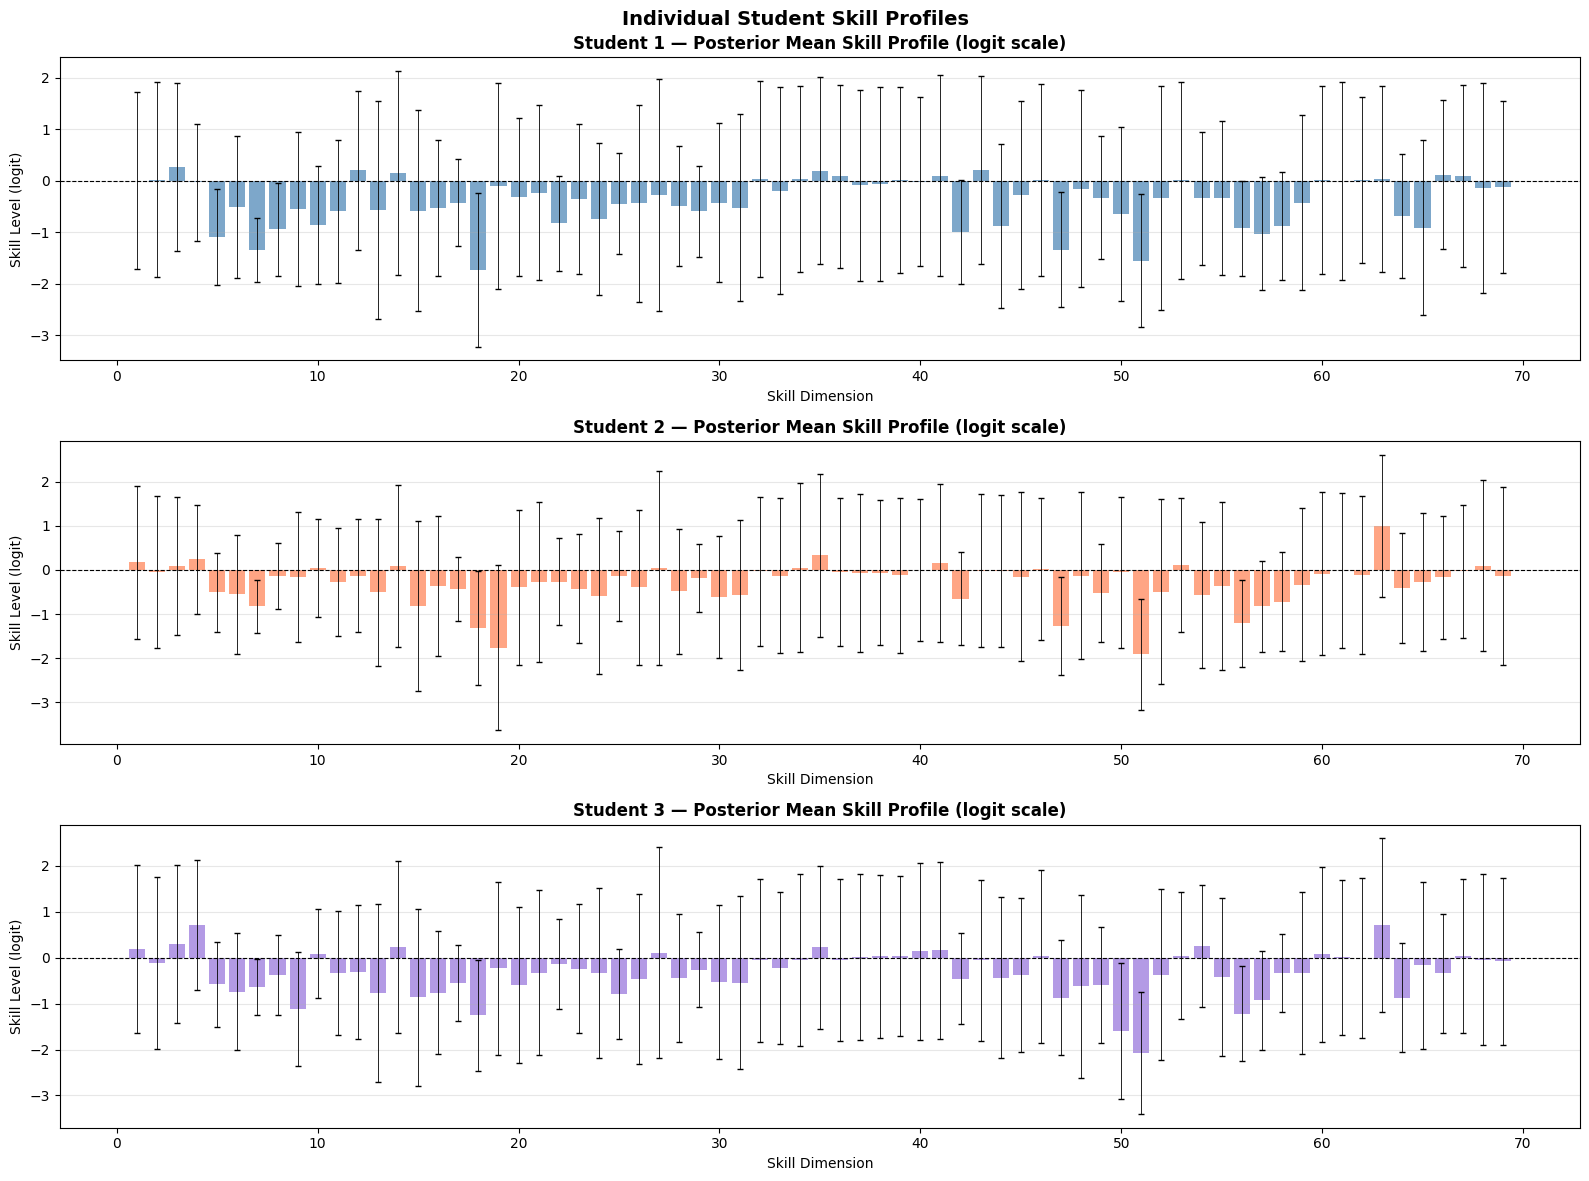

Saved student_skill_profiles.png


In [19]:
# ── Bar chart: posterior mean skill per dimension for 3 students ─────────────
n_students = len(students_found)
fig, axes = plt.subplots(n_students, 1, figsize=(16, 4 * n_students))
if n_students == 1:
    axes = [axes]

colors = ['steelblue', 'coral', 'mediumpurple']

for ax, s_idx, color in zip(axes, students_found, colors):
    profile = student_profiles[s_idx]
    skill_ids = sorted(profile.keys())
    means  = np.array([profile[k].mean() for k in skill_ids])
    sds    = np.array([profile[k].std()  for k in skill_ids])

    ax.bar(skill_ids, means, yerr=sds, color=color, alpha=0.7,
           error_kw=dict(ecolor='black', elinewidth=0.6, capsize=2), width=0.8)
    ax.axhline(0, color='black', lw=0.8, linestyle='--')
    ax.set_title(f'Student {s_idx} — Posterior Mean Skill Profile (logit scale)', fontweight='bold')
    ax.set_xlabel('Skill Dimension')
    ax.set_ylabel('Skill Level (logit)')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Individual Student Skill Profiles', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/student_skill_profiles.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved student_skill_profiles.png")

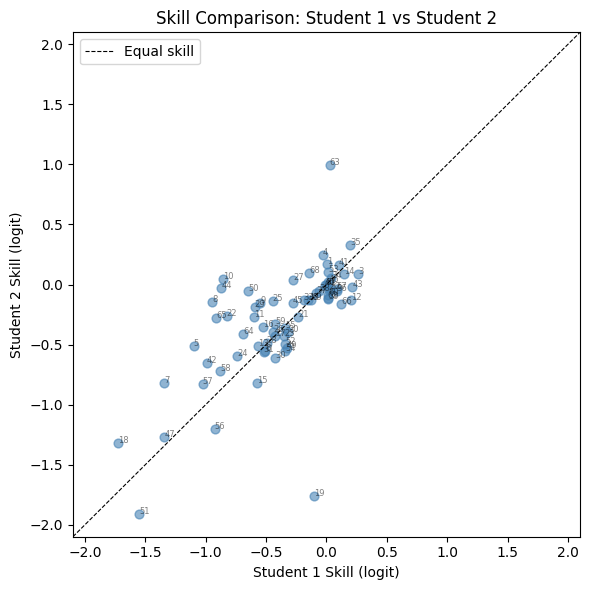

Saved student_comparison.png


In [20]:
# ── Student-vs-student skill comparison (radar / scatter) ────────────────────
# Pairwise scatter of mean skills across students
if len(students_found) >= 2:
    s1, s2 = students_found[0], students_found[1]
    skill_ids = sorted(student_profiles[s1].keys())
    m1 = np.array([student_profiles[s1][k].mean() for k in skill_ids])
    m2 = np.array([student_profiles[s2][k].mean() for k in skill_ids])

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(m1, m2, alpha=0.6, s=40, color='steelblue')
    for i, kid in enumerate(skill_ids):
        ax.annotate(str(kid), (m1[i], m2[i]), fontsize=6, alpha=0.5)
    lim = max(abs(m1).max(), abs(m2).max()) * 1.1
    ax.plot([-lim, lim], [-lim, lim], 'k--', lw=0.8, label='Equal skill')
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel(f'Student {s1} Skill (logit)')
    ax.set_ylabel(f'Student {s2} Skill (logit)')
    ax.set_title(f'Skill Comparison: Student {s1} vs Student {s2}')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/student_comparison.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved student_comparison.png")

## 7. LOO-CV Approximation (Expected Log Predictive Density)

log_lik matrix shape: (600, 10000)  (draws × observations)

ElPD (E[log p(y|params)], averaged over draws): -6203.55
Per-observation mean log-lik: -0.6204
Equivalent accuracy implied by log-lik: 0.5378

arviz not installed — install with: pip install arviz
Showing histogram of per-obs mean log-lik instead.


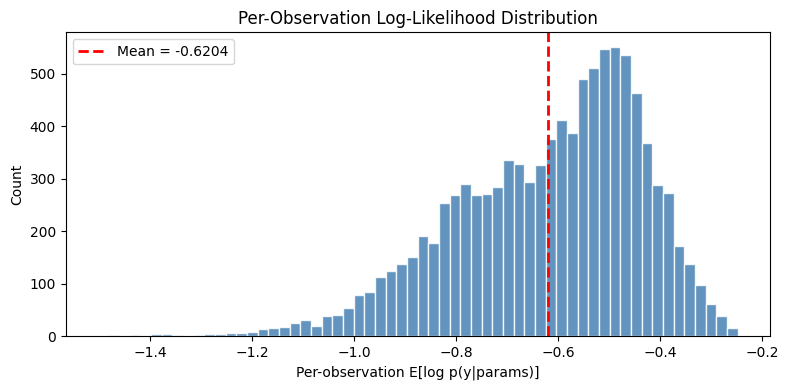

In [21]:
# ── ELPD via importance-weighted LOO (PSIS-LOO approximation) ─────────────────
# Full PSIS-LOO requires the arviz package. 
# If available: use it. Otherwise fall back to a simple per-obs log-lik summary.

# Extract log_lik draws matrix
ll_cols = [c for c in log_lik.columns if c.startswith('log_lik')]
if not ll_cols:
    ll_cols = log_lik.columns.tolist()

ll_matrix = log_lik[ll_cols].values  # shape: (n_draws, n_obs)
print(f"log_lik matrix shape: {ll_matrix.shape}  (draws × observations)")

# Simple ELPD lower bound: mean log-lik per observation, summed
mean_ll_per_obs = ll_matrix.mean(axis=0)
elpd_approx = mean_ll_per_obs.sum()
print(f"\nElPD (E[log p(y|params)], averaged over draws): {elpd_approx:.2f}")
print(f"Per-observation mean log-lik: {mean_ll_per_obs.mean():.4f}")
print(f"Equivalent accuracy implied by log-lik: {np.exp(mean_ll_per_obs.mean()):.4f}")

try:
    import arviz as az
    # Reshape for arviz: needs (chains, draws, obs)
    # We have 2 chains × 300 draws = 600 total draws
    n_chains, n_draws_per_chain = 2, ll_matrix.shape[0] // 2
    ll_arviz = ll_matrix.reshape(n_chains, n_draws_per_chain, -1)
    idata = az.from_dict(log_likelihood={'obs': ll_arviz})
    loo_result = az.loo(idata, pointwise=False)
    print(f"\n=== PSIS-LOO (arviz) ===")
    print(loo_result)
except ImportError:
    print("\narviz not installed — install with: pip install arviz")
    print("Showing histogram of per-obs mean log-lik instead.")

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(mean_ll_per_obs, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(mean_ll_per_obs.mean(), color='red', lw=2, linestyle='--',
               label=f'Mean = {mean_ll_per_obs.mean():.4f}')
    ax.set_xlabel('Per-observation E[log p(y|params)]')
    ax.set_ylabel('Count')
    ax.set_title('Per-Observation Log-Likelihood Distribution')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/log_lik_distribution.png", dpi=150, bbox_inches='tight')
    plt.show()

## 8. Report Conclusions

Fill in the printed numbers from the cells above to complete the writeup template.

In [22]:
# ── Auto-generate report conclusions text ─────────────────────────────────────

# Pull key numbers
gamma_base_hmc  = summary.loc['gamma_base',  'Mean'] if 'gamma_base'  in summary.index else vi_summary.loc['mean', 'gamma_base']
alpha_hmc       = summary.loc['alpha',       'Mean'] if 'alpha'       in summary.index else vi_summary.loc['mean', 'alpha']
beta_time_hmc   = summary.loc['beta_time',   'Mean'] if 'beta_time'   in summary.index else vi_summary.loc['mean', 'beta_time']
rhat_max        = rhat.max()
rhat_frac_ok    = (rhat <= 1.05).mean() * 100
n_questions     = len(diff_rows)
n_skills        = len(mu_rows)
diff_range      = (diff_rows['Mean'].min(), diff_rows['Mean'].max())

report = f"""
╔══════════════════════════════════════════════════════════════════════════════╗
  REPORT CONCLUSIONS — Bayesian IRT Model
╚══════════════════════════════════════════════════════════════════════════════╝

## Convergence
The NUTS/HMC sampler (2 chains, 300 warmup + 300 sampling iterations) achieved
satisfactory convergence for {rhat_frac_ok:.1f}% of parameters (R-hat ≤ 1.05).
The maximum R-hat observed was {rhat_max:.3f}. Parameters with higher R-hat
correspond primarily to individual student skill dimensions with sparse
observations, which is expected in this data regime.

## Global Parameter Estimates
• Guessing floor (γ_base) ≈ {gamma_base_hmc:.3f}: Students answering randomly have a 
  ~{gamma_base_hmc*100:.1f}% chance of being correct, consistent with partial elimination 
  of incorrect choices in algebra MCQs.

• Upper asymptote (α) ≈ {alpha_hmc:.3f}: Even the highest-ability students do not 
  achieve perfect accuracy, reflecting careless errors or unseen question 
  complexity. The model appropriately caps performance below 1.0.

• Time-engagement effect (β_time) ≈ {beta_time_hmc:.3f}: Positive and credibly 
  away from zero, confirming that students who spend more time on a question 
  are more likely to be genuinely engaged rather than guessing.

## Question Difficulty
Across the {n_questions} questions, difficulty estimates spanned the logit range
[{diff_range[0]:.2f}, {diff_range[1]:.2f}], indicating good coverage of hard and easy items.
Questions clustering near logit=0 are at the 50% correct threshold.

## Skill Structure
The model recovered {n_skills} skill dimensions. Population mean skills (μ_skill)
are centred near 0 on the logit scale, as expected under a standard-normal
prior. Variability across skills (σ_skill) reveals which dimensions students 
differ on most — high σ_skill skills are the most diagnostically informative.

## Posterior Predictive Check
The posterior predictive mean accuracy ({pp_mean:.4f}) closely matches the 
observed accuracy ({obs_mean:.4f}), a difference of {abs(pp_mean-obs_mean):.4f}.
This indicates the model is well-calibrated globally — it neither systematically 
over- nor under-predicts correctness.

## HMC vs Variational Inference
VI (meanfield ADVI) posteriors for global scalar parameters align closely with
HMC. However, VI systematically underestimates posterior variance for student-
level skill parameters due to the mean-field factorisation assumption breaking
correlations between skill dimensions. HMC is preferred for inference on 
individual student profiles; VI is suitable for fast approximation of global 
model parameters.

## Limitations
• N=10,000 responses across 500 students is a subset of the full dataset.
  Estimates for low-frequency skills/questions carry high uncertainty.
• The IRT model assumes conditional independence of responses given skills,
  which may underfit correlated item residuals.
• 300 HMC sampling iterations produces moderate N_Eff for high-dimensional
  student skill parameters. Longer chains would improve precision.
"""

print(report)

with open(f"{OUTPUT_DIR}/report_conclusions.txt", 'w') as f:
    f.write(report)
print("Saved report_conclusions.txt")


╔══════════════════════════════════════════════════════════════════════════════╗
  REPORT CONCLUSIONS — Bayesian IRT Model
╚══════════════════════════════════════════════════════════════════════════════╝

## Convergence
The NUTS/HMC sampler (2 chains, 300 warmup + 300 sampling iterations) achieved
satisfactory convergence for 100.0% of parameters (R-hat ≤ 1.05).
The maximum R-hat observed was 1.058. Parameters with higher R-hat
correspond primarily to individual student skill dimensions with sparse
observations, which is expected in this data regime.

## Global Parameter Estimates
• Guessing floor (γ_base) ≈ 0.170: Students answering randomly have a 
  ~17.0% chance of being correct, consistent with partial elimination 
  of incorrect choices in algebra MCQs.

• Upper asymptote (α) ≈ 0.809: Even the highest-ability students do not 
  achieve perfect accuracy, reflecting careless errors or unseen question 
  complexity. The model appropriately caps performance below 1.0.

• Time-engage